In [ ]:
\
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt


In [ ]:
# importing data
df = pd.read_csv("linear_regression_dataset.csv")
print(df.head())


FileNotFoundError: [Errno 2] No such file or directory: 'linear_regression_dataset.csv'

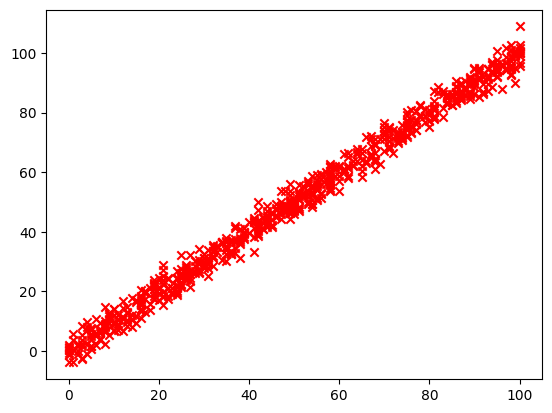

In [ ]:
x = np.array([i for i in df["x"]])
y = np.array([i for i in df["y"]])

idx = np.where(np.isnan(y))[0][0]

x = np.delete(x, idx)
y = np.delete(y, idx)

#for i in range(700):
#   print(f"({x[i]},{y[i]})")

plt.scatter(x, y, marker='x', label='Training Data',color = "red")


In [ ]:
"""
    Functions for
    - computing Cost function
    - computing differential (dJ/dw & dJ/db)
    - computing gradient descent
"""
def compute_cost(x,y,w,b):
    m = len(x)
    cost = 0

    for i in range(m):
        y_pred = w*x[i]+b
        cost += (y_pred - y[i])**2
    
    cost = cost/(2*m)
    return cost


def compute_differential(x,y,w,b):
    dj_dw = 0
    dj_db = 0

    m = len(x)

    for i in range(m):
        y_pred = w*x[i]+b
        dj_dw += (y_pred-y[i])*x[i]
        dj_db += (y_pred-y[i])

    dj_dw/=m
    dj_db/=m

    return dj_dw,dj_db

def compute_gradient_descent(x,y,w,b,alpha,epochs):
    cost_history = []
    w_history = []
    b_history = []

    for i in range(epochs):
        dj_dw, dj_db = compute_differential(x, y, w, b)
    
        #if i % 10 == 0:
        #    print(i, w, b, dj_dw, dj_db)
    
        w -= alpha * dj_dw
        b -= alpha * dj_db
        cost_history.append(compute_cost(x,y,w,b))
        w_history.append(w)
        b_history.append(b)
        
    return w,b,cost_history,w_history,b_history



# main implementation
w = 0
b = 0
w, b, cost_history,w_history,b_history = compute_gradient_descent(
    x, y, w, b,
    alpha=1e-5,
    epochs=1000
)

print(f"w={w}")
print(f"b={b}")


w=0.9988297525354068
b=0.014658111760022942


[np.float64(3.9357401790304207), np.float64(3.935740169685369), np.float64(3.93574016034035), np.float64(3.9357401509953847), np.float64(3.9357401416504585)]


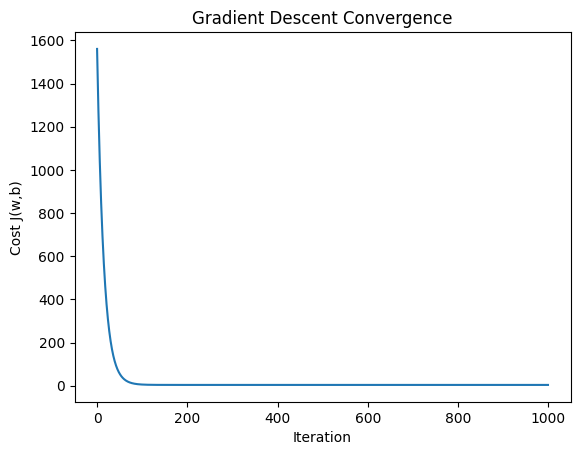

In [ ]:
# cost func implementation plot
# print(cost_history[-5:])
plt.plot(cost_history)

plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Gradient Descent Convergence")

plt.show()


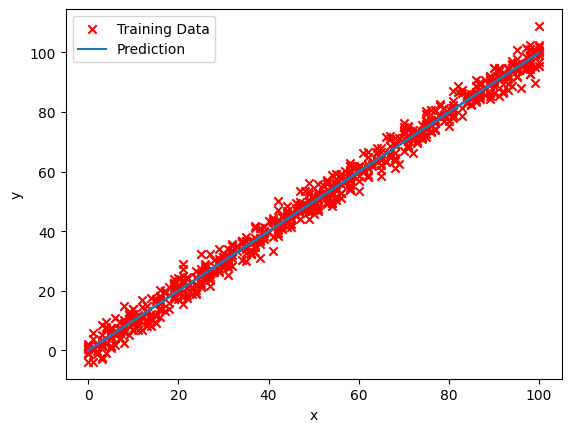

In [ ]:
#final result
plt.scatter(x, y, marker='x', label='Training Data',color = "red")

y_hat = w*x+b

plt.plot(x,y_hat,label="Prediction")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()
